In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import numpy as np

In [2]:
RESULTS_DIR = 'results4'
SEND_COLS = ['t_send', 'seq', 'bytes', 'src_ip'] 
RECV_COLS = ['t_recv', 'seq', 'bytes', 'src_ip', 'src_port'] 
QUEUE_COLS = ['time', 'backlog', 'dropped']

def load_csv(filepath, cols=None):
    if not os.path.exists(filepath):
        print(f"[WARN] Không tìm thấy file: {filepath}")
        return pd.DataFrame()
    
    try:
        df = pd.read_csv(filepath)
        df.columns = [c.strip() for c in df.columns]
        return df
    except Exception as e:
        print(f"[ERR] Lỗi đọc file {filepath}: {e}")
        return pd.DataFrame()

In [3]:
def analyze_flow(flow_name, send_df, recv_df, queue_dfs=None, title_suffix=""):
    print(f"\n{'='*20} PHÂN TÍCH FLOW: {flow_name} {'='*20}")
    
    if send_df.empty:
        print("Không có dữ liệu gửi.")
        return

    # 1. Thống kê cơ bản
    total_sent = len(send_df)
    total_recv = len(recv_df)
    loss_rate = (1 - total_recv / total_sent) * 100 if total_sent > 0 else 0
    
    print(f"-> Tổng gửi: {total_sent} pkts")
    print(f"-> Tổng nhận: {total_recv} pkts")
    print(f"-> Tỉ lệ mất gói (Loss): {loss_rate:.2f}%")

    # 2. Tính Throughput (Băng thông nhận)
    if not recv_df.empty:
        # Đổi tên cột thời gian để resample
        recv_df['datetime'] = pd.to_datetime(recv_df.iloc[:, 0], unit='s')
        recv_df = recv_df.set_index('datetime')
        
        # Tính tổng bytes trong mỗi giây -> Mbps
        thru = recv_df.iloc[:, 2].resample('1s').sum() * 8 / 1e6 # cột bytes thường là index 2
        
        plt.figure(figsize=(10, 4))
        plt.plot(thru.index, thru.values, label='Throughput (Recv)', color='green')
        plt.title(f"Throughput - {flow_name}")
        plt.ylabel("Mbps")
        plt.xlabel("Time")
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()
        plt.show()

    # 3. Tính độ trễ (Latency) - Cần merge theo Sequence
    if not recv_df.empty and not send_df.empty:
        # Giả sử cột 'seq' là cột thứ 2 (index 1)
        # Đổi tên cột cho dễ merge
        s_temp = send_df.copy()
        r_temp = recv_df.copy()
        
        # Lấy tên cột seq chính xác
        seq_col_s = [c for c in s_temp.columns if 'seq' in c.lower()][0]
        seq_col_r = [c for c in r_temp.columns if 'seq' in c.lower()][0]
        
        # Merge
        merged = pd.merge(s_temp, r_temp, left_on=seq_col_s, right_on=seq_col_r, suffixes=('_s', '_r'))
        
        # Tính Latency (ms)
        # Cột thời gian thường là cột đầu tiên
        t_s_col = merged.columns[0]
        t_r_col = merged.columns[len(s_temp.columns)] # Cột đầu của bên phải
        
        merged['latency_ms'] = (merged[t_r_col] - merged[t_s_col]) * 1000
        avg_lat = merged['latency_ms'].mean()
        
        print(f"-> Độ trễ trung bình: {avg_lat:.2f} ms")
        
        # Vẽ Histogram Latency
        plt.figure(figsize=(6, 4))
        plt.hist(merged['latency_ms'], bins=50, color='skyblue', edgecolor='black')
        plt.title(f"Latency Distribution - {flow_name}")
        plt.xlabel("Latency (ms)")
        plt.show()

In [4]:
def plot_queue_comparison(q1_file, q2_file, label1, label2):
    print(f"\n{'='*20} SO SÁNH HÀNG ĐỢI (LOAD BALANCING) {'='*20}")
    
    q1 = load_csv(q1_file)
    q2 = load_csv(q2_file)
    
    if q1.empty and q2.empty:
        print("Không tìm thấy dữ liệu hàng đợi.")
        return

    plt.figure(figsize=(12, 5))
    
    # Hàm plot phụ
    def plot_q(df, lbl, clr):
        if not df.empty:
            # Xử lý thời gian tương đối (bắt đầu từ 0)
            t = df.iloc[:, 0]
            t = t - t.iloc[0]
            # Cột backlog thường là cột chứa chữ 'b' hoặc là cột thứ 2
            # Giả sử file log qdisc monitor có định dạng: time, backlog_bytes, dropped...
            # Ta cần parse cột backlog (đôi khi nó có chữ '1500b')
            # Ở đây giả sử bạn dùng script monitor đơn giản ghi số nguyên:
            plt.plot(t, df.iloc[:, 1], label=lbl, color=clr, alpha=0.8)

    plot_q(q1, label1, 'red')
    plot_q(q2, label2, 'blue')
    
    plt.title("So sánh kích thước hàng đợi (Queue Backlog)")
    plt.ylabel("Bytes / Packets")
    plt.xlabel("Thời gian (s)")
    plt.legend()
    plt.grid(True)
    plt.show()
    print(f"-> Đã vẽ biểu đồ so sánh giữa {label1} và {label2}.")
    print("   (Nếu cả 2 đường đều dao động nghĩa là Load Balancing THÀNH CÔNG)")

Loading Flow A...

==================== PHÂN TÍCH FLOW: Flow A (H1->H4) ====================
-> Tổng gửi: 20027 pkts
-> Tổng nhận: 16228 pkts
-> Tỉ lệ mất gói (Loss): 18.97%


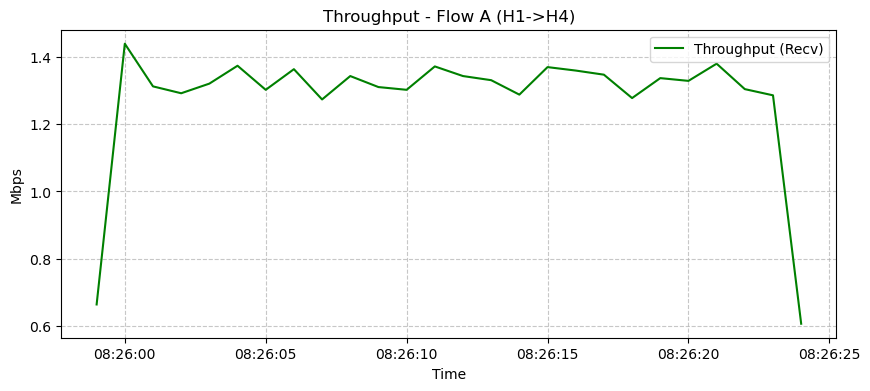

-> Độ trễ trung bình: 30.95 ms


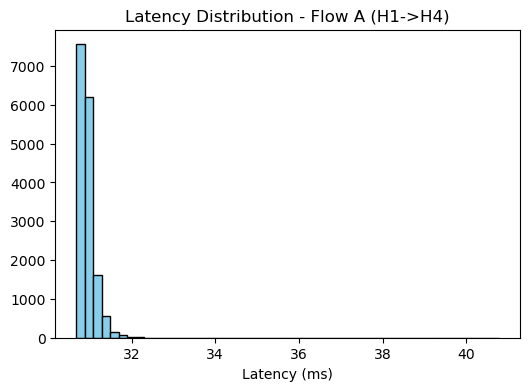

Loading Flow B...

==================== PHÂN TÍCH FLOW: Flow B (H2->H5) ====================
-> Tổng gửi: 12377 pkts
-> Tổng nhận: 2275 pkts
-> Tỉ lệ mất gói (Loss): 81.62%


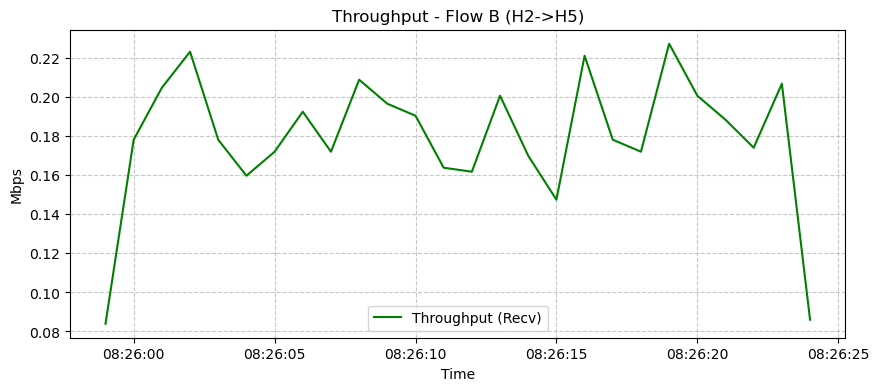

-> Độ trễ trung bình: 41.24 ms


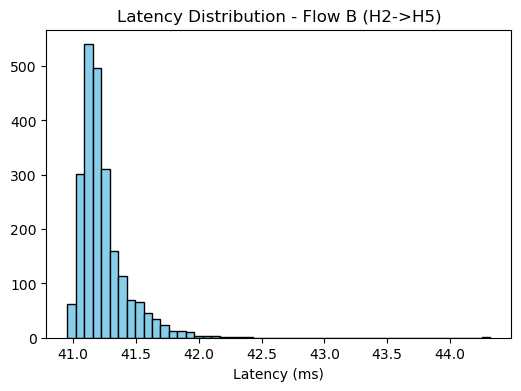

Loading Flow C (Gộp các parts)...

==================== PHÂN TÍCH FLOW: Flow C (H3 -> Load Balanced) ====================
-> Tổng gửi: 7442 pkts
-> Tổng nhận: 2507 pkts
-> Tỉ lệ mất gói (Loss): 66.31%


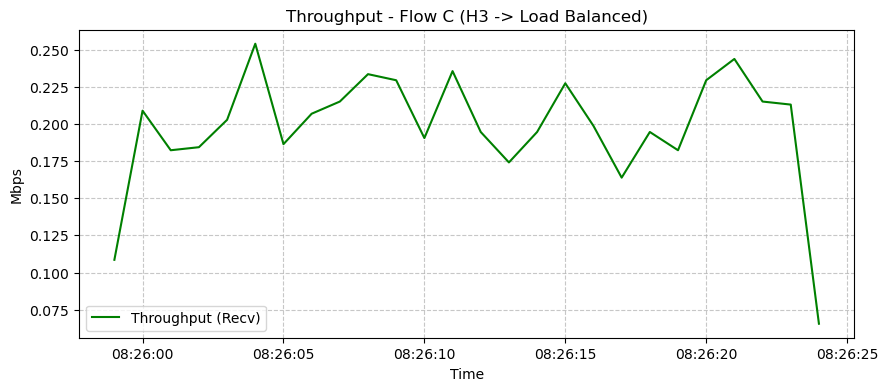

-> Độ trễ trung bình: 31.12 ms


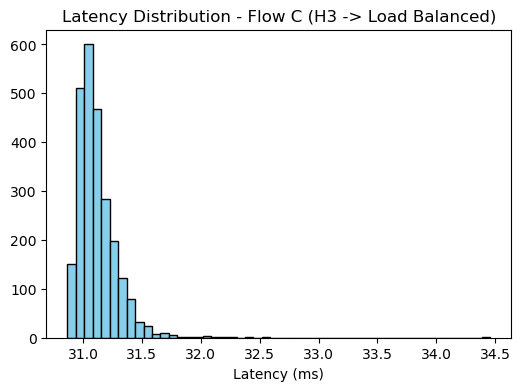


==================== SO SÁNH HÀNG ĐỢI (LOAD BALANCING) ====================


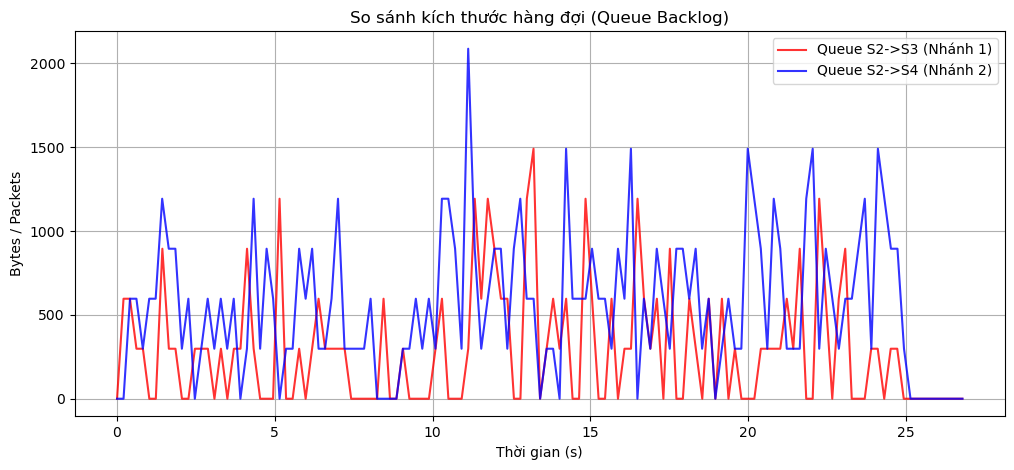

-> Đã vẽ biểu đồ so sánh giữa Queue S2->S3 (Nhánh 1) và Queue S2->S4 (Nhánh 2).
   (Nếu cả 2 đường đều dao động nghĩa là Load Balancing THÀNH CÔNG)


In [10]:
# 1. Phân tích Flow A (H1 -> H4) - Luồng nền
print("Loading Flow A...")
send_a = load_csv(os.path.join(RESULTS_DIR, 'send_A_h1_to_h4.csv'))
recv_a = load_csv(os.path.join(RESULTS_DIR, 'recv_A_h4.csv'))
analyze_flow("Flow A (H1->H4)", send_a, recv_a)

# 2. Phân tích Flow B (H2 -> H5)
print("Loading Flow B...")
send_b = load_csv(os.path.join(RESULTS_DIR, 'send_B_h2_to_h5.csv'))
recv_b = load_csv(os.path.join(RESULTS_DIR, 'recv_B_h5.csv'))
analyze_flow("Flow B (H2->H5)", send_b, recv_b)

# 3. Phân tích Flow C (H3 -> H4/H5) - Luồng Load Balancing
print("Loading Flow C (Gộp các parts)...")
# Tìm tất cả file send_C_part*.csv
c_files = glob.glob(os.path.join(RESULTS_DIR, 'send_C_part*.csv'))
if c_files:
    df_list = []
    for f in c_files:
        df_list.append(load_csv(f))
    send_c = pd.concat(df_list, ignore_index=True)
else:
    # Fallback nếu không chia part (chạy code cũ)
    send_c = load_csv(os.path.join(RESULTS_DIR, 'send_C_h3_to_h4.csv')) # Tên file cũ nếu có

recv_c = load_csv(os.path.join(RESULTS_DIR, 'recv_C_h4.csv')) # Hoặc tên file recv tương ứng
analyze_flow("Flow C (H3 -> Load Balanced)", send_c, recv_c)

# 4. QUAN TRỌNG: Vẽ biểu đồ so sánh hàng đợi tại S2
# Đây là bằng chứng thép cho giải pháp của bạn
q_s2_s3 = os.path.join(RESULTS_DIR, 'queue_s2_s3.csv')
q_s2_s4 = os.path.join(RESULTS_DIR, 'queue_s2_s4.csv')

plot_queue_comparison(q_s2_s3, q_s2_s4, "Queue S2->S3 (Nhánh 1)", "Queue S2->S4 (Nhánh 2)")